In [1]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", version=1, as_frame=False)

In [2]:
X = mnist.data
y = mnist.target.astype(int)

In [3]:
X.shape

(70000, 784)

In [4]:
y.shape

(70000,)

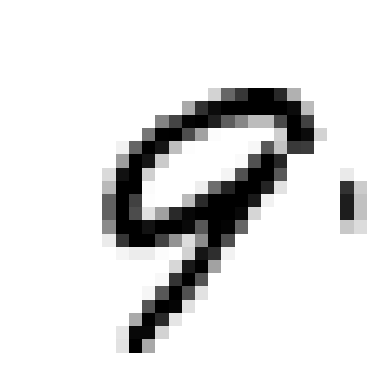

In [14]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt 
some_digit = X[4949]
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap=matplotlib.cm.binary, 
           interpolation='nearest')
plt.axis("off")
plt.show()


In [5]:
y[4949]

9

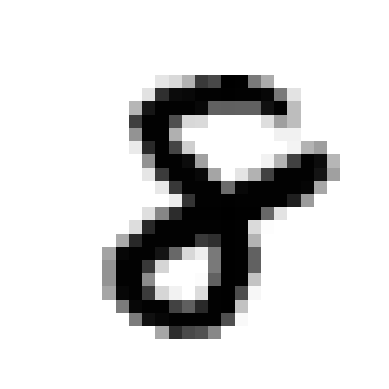

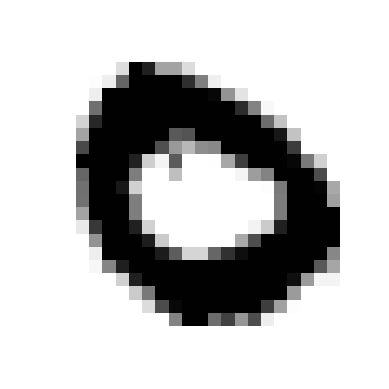

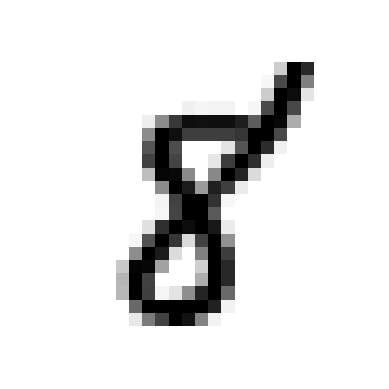

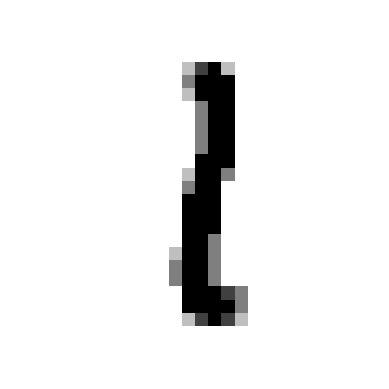

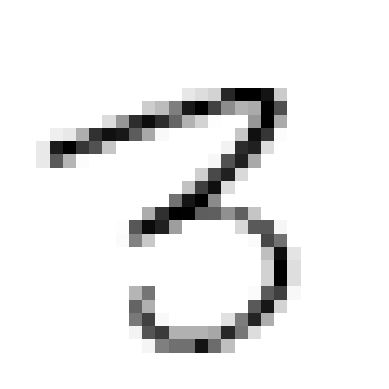

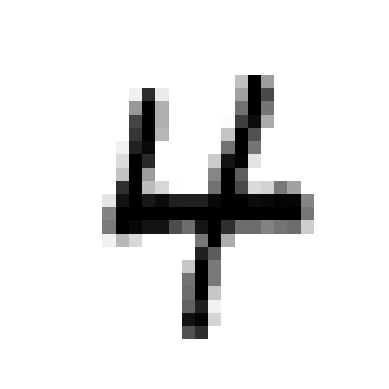

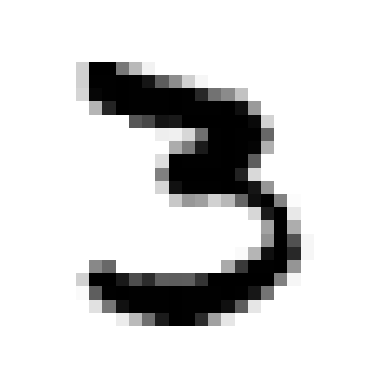

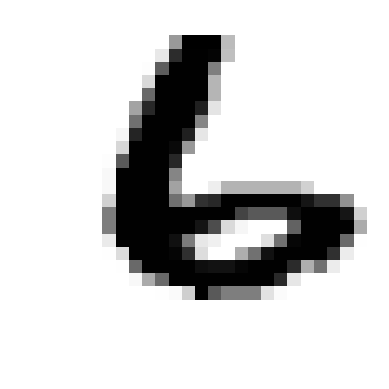

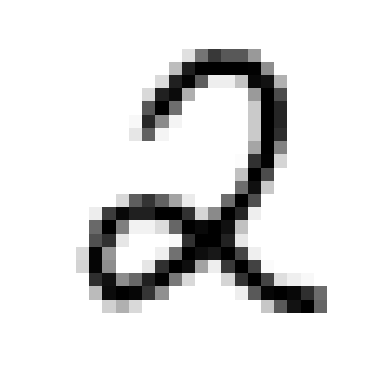

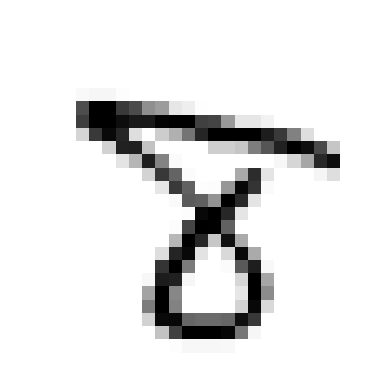

In [17]:
import random
for _ in range(10):
    idx = random.randrange(0, X.shape[0])   # single integer
    some_digit = X[idx]
    some_digit_image = some_digit.reshape(28, 28)

    plt.imshow(some_digit_image, cmap=matplotlib.cm.binary, interpolation='nearest')
    plt.axis("off")
    plt.show()

### Split the data into training and test set 

In [6]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [7]:
X_train.shape

(60000, 784)

In [8]:
y_test.shape

(10000,)

In [9]:
# Now shuffle the training set data for cross validation. 
import numpy as np 

shuffle_index = np.random.permutation(60000)
X_train, y_train = X_train[shuffle_index], y_train[shuffle_index]

First let's train the model to classify only digit that is 5. 

In [ ]:
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

**Use SGDClassifier class**

The SGDClassifier relies on randomness during training (hence the name "stochastic")

In [11]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [48]:
some_digit = X[27375]

In [47]:
y[27375]

5

In [49]:
sgd_clf.predict([some_digit])

array([ True])

## Performance Measures 

Evaluating a classifier is often significantly trickier than evaluating a regressor. 



In [59]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skflods = StratifiedKFold(n_splits=3)


for train_index, test_index in skflods.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = (y_train_5[train_index])
    X_test_folds = X_train[test_index]
    y_test_folds = (y_train_5[test_index])
    
    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_folds)
    n_correct = sum(y_pred == y_test_folds)
    print(n_correct / len(y_pred))



0.9544
0.96045
0.9316


In [60]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.9544 , 0.96045, 0.9316 ])

**A Dumb classifier**

In [61]:
from sklearn.base import BaseEstimator

class Naver5Classifier(BaseEstimator):
    
    def fit(self, X, y=None):
        pass
    
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool)

In [62]:
never_5_clf = Naver5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.90655, 0.9107 , 0.9117 ])

**This demonstration show why accuracy is generally not the preferred performance measure for classifier, especially when you are dealing with skewed datasets.**

## Confusion Matrix 

The general idea is to count the number of times instances of class A are classified as class B. 

For example, to know the number of times the classifier confused images of 5s with 3s, you would look in the 5th row and 3rd column of the confusion matrix. 

We use **Confusion Matrix** at the end when we are ready with our model to lunch. Instead you can use the cross_val_predict() function. 

Just like the cross_val_score() function, cross_val_predict() performs K-fold cross-validation, but instead of returning the evaluation scores, it returns the predictions made on each test fold. 

In [64]:
from sklearn.model_selection import cross_val_predict

score = cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')
prediction = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [65]:
print(score)
print('-'*50)
print(prediction)

[0.9544  0.96045 0.9316 ]
--------------------------------------------------
[False False False ...  True False False]


In [66]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_train_5, prediction)

array([[52257,  2322],
       [  749,  4672]])

Each row in a confusion matrix represents an actual class. While each column represent a predicted class. 

**Precision**
&
**Recall**

In [67]:
from sklearn.metrics import precision_score, recall_score
print(precision_score(y_train_5, prediction))
print('-'*20)
print(recall_score(y_train_5, prediction))

0.668001143837575
--------------------
0.8618336100350489


It claims an image represents a 5, it is correct only 66% of the time. Moreover, it only detects 86% of the 5s. 

In [70]:
print(4672/ (4672 + 2322))
print('-'*20)
print(4672 / (4672 + 748))

0.668001143837575
--------------------
0.8619926199261992


### F1 

It's often to conventient to combine precision and recall into a single metric called the f1 score. 

In [71]:
from sklearn.metrics import f1_score
f1_score(y_train_5, prediction)

0.7526379379782521

Sometime we need high precision and low recall. This depends on problem statement. 

You are making a claasifier to detect video that are safe for kids. Here percision will be perfer because it some might not recommend some good video for kids but also there is higher chance that it will not recommend any harmful video related to kids. 

You are making a cancer classifier to detect cancer in this recall will have higher weighted. because it might detect cancer to those patient who don't have cancer but almost all cancer patient will detected. 

Unfortunately, you can't have it both ways: increasing precision reduces recall, and vice versa. This is called precision/recall tradeoff. 

In [72]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([1175.84567517])

In [74]:
threshold = 0 
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [75]:
threshold = 200000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

**This confirms that raising the threshold decrease recall.**

The image actually represents a 5, and the classifier detects it when the threshold is 0, but it misses it when the threshold is increased to 200,000.

So how can you decide which threshold to use? For this you will first need to get the scores of all instances in the training set using the cross_val_predicts() function again, but this time specifying that you want it to return decision scores instead of predictions: 

In [76]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv = 3, method="decision_function")

In [77]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

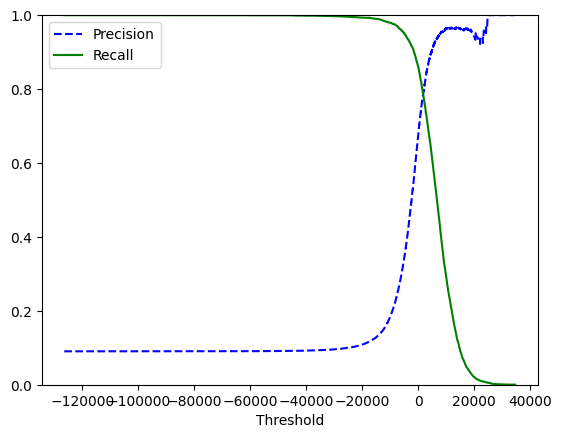

In [83]:
# Plot the precision and recall as functions of the threshold value using matplotlib.
import matplotlib.pyplot as plt  

import matplotlib.pyplot as plt  

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])

plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()


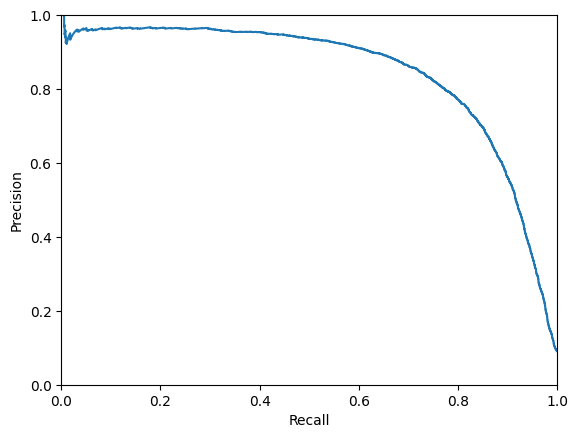

In [86]:
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.ylim([0, 1])
plt.xlim([0, 1])
plt.show()

In [91]:
target_precision = 0.90

idx = np.where(precisions[:-1] >= target_precision)[0][-1]
best_threshold = thresholds[idx]
print(best_threshold, precisions[idx], recalls[idx])

34746.77483045641 1.0 0.00018446781036709093


You decide to aim for 90% precision. 


In [96]:
y_train_pred_90 = (y_scores > 5000)

In [97]:
precision_score(y_train_5, y_train_pred_90)

0.9056295893391352

In [98]:
recall_score(y_train_5, y_train_pred_90)

0.6142778085224129

I created a 90% precision classifier. As you can see, it is fairly easy to create a classifier with virtually any precision you want: just set a high enough threshold, and you're not done. Hmm, not so fast. A high-precision classifier is not very useful if its recall is too low!

## The ROC Curve

It is very similar to the precision/recall vurve, but instead of ploting precision versus recall, the ROC curve plots the true positive rate (recall name) against the false positive rate. 

In [99]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

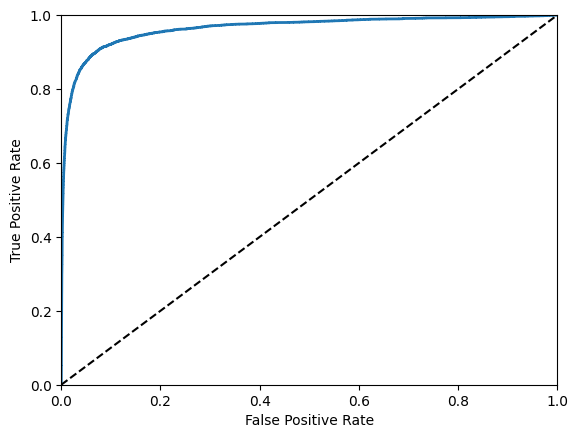

In [100]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    
plot_roc_curve(fpr, tpr)
plt.show()

In [101]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

0.9644947847327844

Since the ROC curve is so similar to the precision/recall curve, you may wonder how to decide which one to use. As a rule of thumb, you should prefer the PR curve whenever the positive class is rare or when you care about the false positive than the false negatives, and the ROC curve otherwise. 

In [103]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method='predict_proba')

The RandomForestClassifier class does not have a decision_function() method. Instead it has a predict_proba() method. Scikit-Learn classifiers generally have one or the other. The predict_proba() method returns an array containing a row per instance and a column per class, each containing the probability that the given instance belongs to the given class(70% chance that the image represents a 5)

In [ ]:
# But to plot ROC curve, you need scores, not probabilites. 
# A simple solution is to use the positive class's probability as the scores:

y_score_forest = y_probas_forest[:, 1]

fpr_forest, tpr_forest, threshold_forest = roc_curve(y_train_5, y_score_forest)

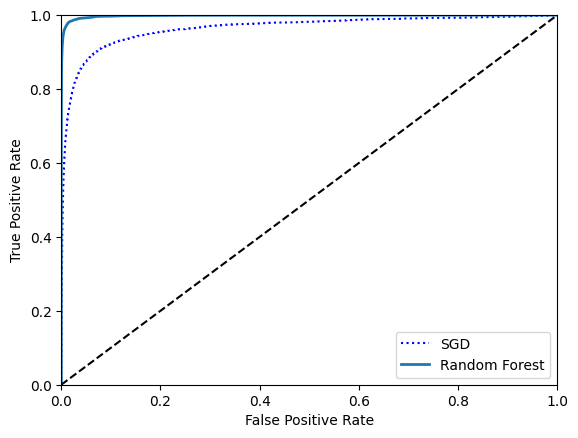

In [106]:
plt.plot(fpr, tpr, 'b:', label='SGD')
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc='best')
plt.show()

In [107]:
roc_auc_score(y_train_5, y_score_forest)

0.9983167155986807

In [111]:
threshold = 0.9   # example — pick based on your PR curve

y_pred_forest = (y_score_forest >= threshold)

from sklearn.metrics import precision_score
print(precision_score(y_train_5, y_pred_forest))


1.0


In [112]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_score_forest)


array([0.09035   , 0.1559802 , 0.2172693 , 0.27701666, 0.33405292,
       0.39237571, 0.4434975 , 0.49555413, 0.54083267, 0.58446056,
       0.6237555 , 0.65834862, 0.69081567, 0.72211771, 0.74933668,
       0.77231435, 0.79506613, 0.81390032, 0.83081477, 0.84827257,
       0.8605178 , 0.87434124, 0.88547066, 0.89638186, 0.90420601,
       0.91297551, 0.92025294, 0.92793752, 0.93393017, 0.94034707,
       0.94536514, 0.94951349, 0.95217873, 0.95701526, 0.96098293,
       0.96446796, 0.96671105, 0.9686724 , 0.97037322, 0.97287347,
       0.97448383, 0.97649363, 0.97815391, 0.98054784, 0.98203234,
       0.98249145, 0.98380567, 0.98592698, 0.98785758, 0.98882219,
       0.99017969, 0.99074853, 0.99173729, 0.99273659, 0.99289406,
       0.9932594 , 0.99343401, 0.99360247, 0.99397859, 0.99415599,
       0.99408822, 0.99518459, 0.99536501, 0.99577861, 0.99620133,
       0.99615846, 0.99708242, 0.99705015, 0.99700748, 0.99696126,
       0.99717224, 0.99764398, 0.99839915, 0.99836512, 0.99833

### Multiclass Classification 

Some algo are able to perfrom multiclass Classification (such as Random Forest or Naive Bayes)

One apporch is to train system that can classify the digit images from (1 t0 9) is to train one for each digit ( 0-detector, 1-detector) known as one-versus-the-rest(OvA)

Another is one-versus-one. train a binary classifier for every pair of digits. 0s and 1s another to distinguish 0s and 2s and so. Using (OvO) strategy. if there are N classes, you need to train N x (N - 1) / 2 classifiers. 

For most binary classification algorithms, however OvA is preferred

Sckikit-Learn detects when you try to use a binary classification algorithm for a multiclass classification task, and it automatically runs OvA (Except for SVM classifiers for which it uses OvO)

In [114]:
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array([5])

In [115]:
some_digit_scores = sgd_clf.decision_function([some_digit])
some_digit_scores

array([[-59179.20121186, -68682.82058601, -18212.46311615,
         -4580.11201625, -23826.6792546 ,   4474.53509828,
        -51089.28465606, -10241.98940024,  -6234.86518012,
         -1352.25030311]])

In [116]:
np.argmax(some_digit_scores)

5

In [117]:
sgd_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [118]:
from sklearn.multiclass import OneVsOneClassifier
ovo_clf = OneVsOneClassifier(SGDClassifier(random_state=42))
ovo_clf.fit(X_train, y_train)
ovo_clf.predict([some_digit])

array([5])

In [119]:
len(ovo_clf.estimators_)

45

In [120]:
forest_clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [121]:
forest_clf.predict([some_digit])

array([5])

In [122]:
forest_clf.predict_proba([some_digit])

array([[0.  , 0.  , 0.  , 0.01, 0.01, 0.92, 0.  , 0.  , 0.03, 0.03]])

In [123]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring='accuracy')

array([0.8827 , 0.87755, 0.877  ])

In [124]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring='accuracy')


/Users/sanjaymahto/Python/.venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.90555, 0.8979 , 0.90335])

### Error Analysis 

You can look at the confusion matrix. You need to make prediction using the cross_val_predict() function, then call the confusion_matrix() function, just like you did earlier: 

In [125]:
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
conf_mx = confusion_matrix(y_train, y_train_pred)
conf_mx

/Users/sanjaymahto/Python/.venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([[5615,    0,   15,    9,    9,   37,   32,    5,  200,    1],
       [   0, 6423,   41,   20,    3,   46,    5,    8,  184,   12],
       [  27,   33, 5267,   90,   76,   23,   69,   35,  329,    9],
       [  26,   21,  117, 5243,    1,  213,   28,   44,  373,   65],
       [  12,   14,   41,   10, 5251,   11,   42,   21,  271,  169],
       [  26,   20,   27,  158,   52, 4487,   78,   12,  496,   65],
       [  27,   19,   46,    2,   38,   94, 5563,    8,  121,    0],
       [  19,   13,   51,   25,   51,   14,    6, 5719,  154,  213],
       [  15,   62,   42,   91,    2,  132,   32,    6, 5418,   51],
       [  25,   22,   30,   57,  128,   39,    1,  176,  321, 5150]])

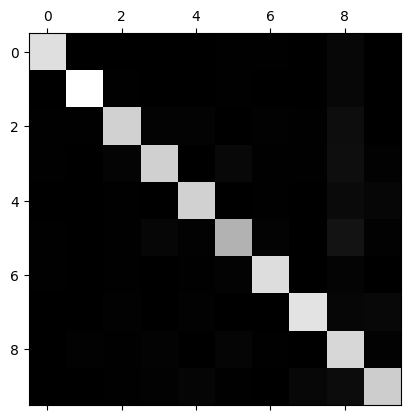

In [126]:
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

In [127]:
row_sums = conf_mx.sum(axis=1, keepdims=True)
norm_conf_mx = conf_mx / row_sums

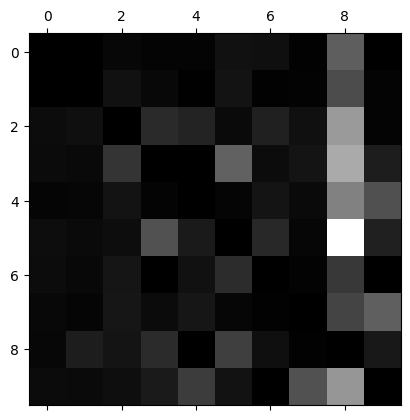

In [129]:
np.fill_diagonal(norm_conf_mx, 0)
plt.matshow(norm_conf_mx, cmap=plt.cm.gray)
plt.show()

In [130]:
import matplotlib.pyplot as plt
import numpy as np

def plot_digits(instances, images_per_row=5):
    size = 28
    images = [instance.reshape(size, size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    for row in range(n_rows):
        start = row * images_per_row
        end = start + images_per_row
        row_images.append(np.concatenate(images[start:end], axis=1))
    full_image = np.concatenate(row_images, axis=0)
    plt.imshow(full_image, cmap="binary")
    plt.axis("off")


In [128]:
cl_a, cl_b = 3, 5 
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]



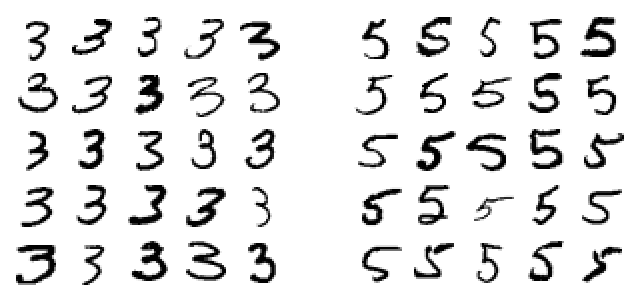

In [131]:
plt.figure(figsize=(8,8))
plt.subplot(221); plot_digits(X_aa[:25], images_per_row=5)
plt.subplot(222); plot_digits(X_ab[:25], images_per_row=5)
plt.subplot(222); plot_digits(X_ba[:25], images_per_row=5)
plt.subplot(222); plot_digits(X_bb[:25], images_per_row=5)
plt.show()

### Multilabel Classification 
Means more then one output. 

In [132]:
from sklearn.neighbors import KNeighborsClassifier
y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [134]:
knn_clf.predict([some_digit])

array([[False,  True]])

In [135]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_train, cv=3)
f1_score(y_train, y_train_knn_pred, average='macro')

0.9689306134692133